<a href="https://colab.research.google.com/github/DeepFluxion/2026_2_IBMEC_PROG_ANALISE_DADOS/blob/main/notebooks/Aula_2026_09_16_data_Prep.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="https://keystoneacademic-res.cloudinary.com/image/upload/c_pad,w_640,h_304/dpr_auto/f_auto/q_auto/v1/element/94/94774_thumb.png" width=300>

# Programação para Análise de Dados
## Aula Especial: Preparação de Dados e Introdução ao Machine Learning
### Prof. Domingos Napolitano

---

| Bloco | Tema | Tempo |
|---|---|---|
| 1 | Motivação — o pipeline de um projeto de ML | 0–10 min |
| 2 | Encoding de variáveis categóricas | 10–40 min |
| 3 | Escalonamento de variáveis | 40–65 min |
| 4 | Introdução ao Machine Learning | 65–80 min |
| 5 | Projeto integrado — Seguro Saúde | 80–90 min |

In [1]:
# ✅ Verificação e instalação automática do scikit-learn
import subprocess, sys

try:
    import sklearn
    print(f"✅ scikit-learn já instalado — versão {sklearn.__version__}")
except ImportError:
    print("⚠️ scikit-learn não encontrado. Instalando, aguarde...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "scikit-learn"])
    import sklearn
    print(f"✅ scikit-learn instalado com sucesso — versão {sklearn.__version__}")

✅ scikit-learn já instalado — versão 1.6.1


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score

np.set_printoptions(suppress=True)
print("✅ Bibliotecas importadas com sucesso!")

✅ Bibliotecas importadas com sucesso!


---
## 🎯 Bloco 1 — Motivação: o Pipeline de um Projeto de ML
⏱️ *0–10 min*

### Por que precisamos preparar os dados?

A maioria dos algoritmos de Machine Learning **só trabalha com números**.
Além disso, variáveis em escalas muito diferentes podem **distorcer** os resultados.

O pipeline típico de um projeto de ML é:

```
📂 Dados Brutos
    ↓
🔤 Encoding        ← converter texto em números   (Bloco 2)
    ↓
📏 Escalonamento   ← colocar tudo na mesma escala (Bloco 3)
    ↓
✂️  Treino / Teste  ← separar os dados corretamente (Bloco 4)
    ↓
🤖 Modelo de ML    ← treinar e avaliar             (Bloco 5)
```

> **Dado limpo e bem preparado é mais importante do que um algoritmo sofisticado.**

---
## 🔤 Bloco 2 — Encoding de Variáveis Categóricas
⏱️ *10–40 min*

### 2.1 Por que codificar?

Variáveis como `'Cor'`, `'Cidade'` ou `'Gênero'` são **textos** — e algoritmos de ML não conseguem processar texto diretamente.

Precisamos converter essas categorias em **números** de forma inteligente, sem criar informações falsas sobre a relação entre elas.

In [3]:
# Exemplo inicial — variável categórica e dummy manual
dados = {"Cor": ["Vermelho", "Azul", "Verde", "Vermelho", "Azul"]}
df = pd.DataFrame(dados)
print("DataFrame original:")
print(df)

# Criando uma dummy manualmente para "Vermelho"
df["e_Vermelho"] = df["Cor"].apply(lambda x: 1 if x == "Vermelho" else 0)
print("\nVariável dummy criada manualmente:")
print(df)

DataFrame original:
        Cor
0  Vermelho
1      Azul
2     Verde
3  Vermelho
4      Azul

Variável dummy criada manualmente:
        Cor  e_Vermelho
0  Vermelho           1
1      Azul           0
2     Verde           0
3  Vermelho           1
4      Azul           0


### 2.2 Label Encoding vs. One-Hot Encoding

| Técnica | Como funciona | Quando usar |
|---|---|---|
| **Label Encoding** | Atribui um inteiro a cada categoria (0, 1, 2…) | Variáveis **ordinais** (há uma ordem: Ruim < Bom < Ótimo) |
| **One-Hot Encoding** | Cria uma coluna binária (0 ou 1) para cada categoria | Variáveis **nominais** (sem ordem: cores, cidades, países) |

> ⚠️ **Atenção:** usar Label Encoding em variáveis **nominais** cria uma **ordem artificial** que pode confundir o modelo — vermelho não é "maior" que azul!

In [4]:
# Label Encoding
le = LabelEncoder()
df_le = df[["Cor"]].copy()
df_le["Cor_encoded"] = le.fit_transform(df_le["Cor"])
print("Label Encoding:")
print(df_le)
print(f"\nMapeamento: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# One-Hot Encoding com pd.get_dummies()
df_ohe = pd.get_dummies(df[["Cor"]], columns=["Cor"], prefix="Cor")
print("\nOne-Hot Encoding:")
print(df_ohe)

Label Encoding:
        Cor  Cor_encoded
0  Vermelho            2
1      Azul            0
2     Verde            1
3  Vermelho            2
4      Azul            0

Mapeamento: {'Azul': np.int64(0), 'Verde': np.int64(1), 'Vermelho': np.int64(2)}

One-Hot Encoding:
   Cor_Azul  Cor_Verde  Cor_Vermelho
0     False      False          True
1      True      False         False
2     False       True         False
3     False      False          True
4      True      False         False


### 2.3 `pd.get_dummies()` — parâmetros importantes

```python
pd.get_dummies(
    data,             # DataFrame de entrada
    columns=[...],    # Colunas a codificar
    prefix="...",     # Prefixo para nomear as novas colunas
    drop_first=True   # Remove a 1ª categoria (evita multicolinearidade)
)
```

In [5]:
# get_dummies() com múltiplas colunas
dados2 = {
    "Cidade": ["São Paulo", "Rio de Janeiro", "Belo Horizonte", "São Paulo"],
    "Plano":  ["Básico", "Premium", "Básico", "Premium"]
}
df2 = pd.DataFrame(dados2)
print("DataFrame original:")
print(df2)

df2_dummies = pd.get_dummies(df2, columns=["Cidade", "Plano"], prefix=["Cidade", "Plano"])
print("\nApós get_dummies():")
print(df2_dummies)

DataFrame original:
           Cidade    Plano
0       São Paulo   Básico
1  Rio de Janeiro  Premium
2  Belo Horizonte   Básico
3       São Paulo  Premium

Após get_dummies():
   Cidade_Belo Horizonte  Cidade_Rio de Janeiro  Cidade_São Paulo  \
0                  False                  False              True   
1                  False                   True             False   
2                   True                  False             False   
3                  False                  False              True   

   Plano_Básico  Plano_Premium  
0          True          False  
1         False           True  
2          True          False  
3         False           True  


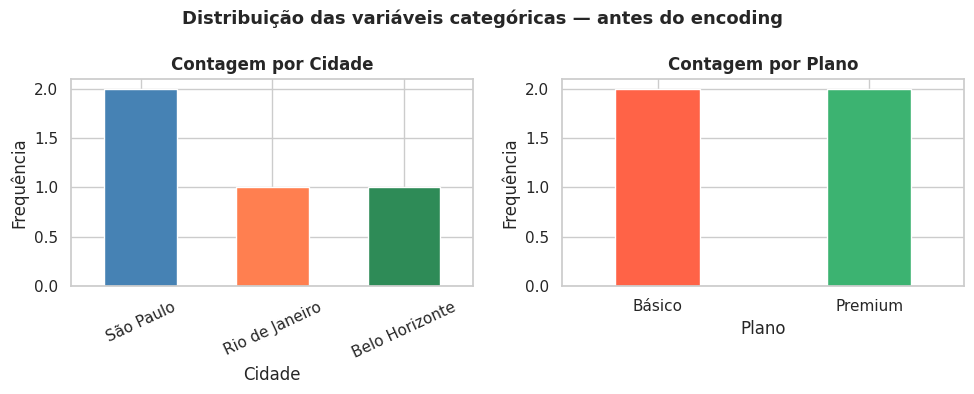


💡 Encoding não altera a distribuição dos dados — apenas muda a representação.


In [6]:
# 📊 Visualizando a distribuição das categorias ANTES do encoding
# (ref. Aula10: gráfico de barras — sns.barplot / .value_counts().plot)
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

df2["Cidade"].value_counts().plot(
    kind="bar", ax=axes[0],
    color=["steelblue","coral","seagreen"], edgecolor="white", width=0.55)
axes[0].set_title("Contagem por Cidade", fontweight="bold")
axes[0].set_xlabel("Cidade"); axes[0].set_ylabel("Frequência")
axes[0].tick_params(axis="x", rotation=25)

df2["Plano"].value_counts().plot(
    kind="bar", ax=axes[1],
    color=["tomato","mediumseagreen"], edgecolor="white", width=0.4)
axes[1].set_title("Contagem por Plano", fontweight="bold")
axes[1].set_xlabel("Plano"); axes[1].set_ylabel("Frequência")
axes[1].tick_params(axis="x", rotation=0)

plt.suptitle("Distribuição das variáveis categóricas — antes do encoding",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()
print("\n💡 Encoding não altera a distribuição dos dados — apenas muda a representação.")

### 2.4 Armadilha das Variáveis Dummy (Multicolinearidade)

Se criarmos **N** dummies para uma variável com **N categorias**, uma delas é **redundante** — basta olhar as outras para saber o valor da que falta.

**Exemplo:** Com `Cidade_SP`, `Cidade_RJ` e `Cidade_BH`, quando as duas primeiras são 0, já sabemos que `Cidade_BH = 1`.

**Solução:** `drop_first=True` — elimina a primeira categoria; ela vira a **referência implícita**.

In [7]:
# Demonstração: com e sem drop_first
print("SEM drop_first=True (3 colunas — redundante):")
print(pd.get_dummies(df2, columns=["Cidade"], prefix="Cidade"))

print("\nCOM drop_first=True (2 colunas — correto):")
print(pd.get_dummies(df2, columns=["Cidade"], prefix="Cidade", drop_first=True))

SEM drop_first=True (3 colunas — redundante):
     Plano  Cidade_Belo Horizonte  Cidade_Rio de Janeiro  Cidade_São Paulo
0   Básico                  False                  False              True
1  Premium                  False                   True             False
2   Básico                   True                  False             False
3  Premium                  False                  False              True

COM drop_first=True (2 colunas — correto):
     Plano  Cidade_Rio de Janeiro  Cidade_São Paulo
0   Básico                  False              True
1  Premium                   True             False
2   Básico                  False             False
3  Premium                  False              True


### 2.5 Variáveis Ordinais — Mapeamento Manual

Quando há **ordem** entre as categorias, o melhor é definir um mapeamento manual que **preserve** essa hierarquia.

**Exemplo:** `P < M < G < GG` → `0, 1, 2, 3`

In [8]:
# Variável ordinal: avaliação de atendimento
dados_ord = {"Avaliacao": ["Ruim", "Bom", "Otimo", "Bom", "Ruim"]}
df_ord = pd.DataFrame(dados_ord)

# Mapeamento manual que preserva a ordem
mapa = {"Ruim": 0, "Bom": 1, "Otimo": 2}
df_ord["Avaliacao_num"] = df_ord["Avaliacao"].map(mapa)

print(df_ord)
print("\nA ordem está preservada: Ruim=0 < Bom=1 < Ótimo=2 ✓")

  Avaliacao  Avaliacao_num
0      Ruim              0
1       Bom              1
2     Otimo              2
3       Bom              1
4      Ruim              0

A ordem está preservada: Ruim=0 < Bom=1 < Ótimo=2 ✓


---
### ✏️ Exercício 1 — Encoding Guiado

Você tem um DataFrame com duas colunas:

- **`Tamanho`** → P, M, G, GG  *(variável ordinal — há uma ordem de tamanho)*
- **`Marca`**   → Nike, Adidas, Puma  *(variável nominal — sem ordem entre marcas)*

**Siga os passos comentados no código abaixo:**

In [9]:
# ── Setup: DataFrame inicial ──────────────────────────────────────────────
df_ex1 = pd.DataFrame({
    "Tamanho": ["P", "G", "M", "GG", "P", "M"],
    "Marca":   ["Nike", "Adidas", "Puma", "Nike", "Puma", "Adidas"]
})
print("DataFrame inicial:"); print(df_ex1)

# ── Passo 1: encode Tamanho com mapeamento manual (ordinal) ───────────────
# Dica: crie mapa_tamanho = {"P": 0, "M": 1, "G": 2, "GG": 3}
#       depois use df_ex1["Tamanho"].map(mapa_tamanho)
mapa_tamanho = {"P": 0, "M": 1, "G": 2, "GG": 3}          # TODO — ajuste se quiser
df_ex1["Tamanho_num"] = df_ex1["Tamanho"].map(mapa_tamanho)  # TODO

# ── Passo 2: encode Marca com get_dummies() (nominal) ─────────────────────
# Dica: use drop_first=True para remover a redundância
df_ex1 = pd.get_dummies(df_ex1, columns=["Marca"], prefix="Marca", drop_first=True)  # TODO

print("\nDataFrame após encoding:")
print(df_ex1)

DataFrame inicial:
  Tamanho   Marca
0       P    Nike
1       G  Adidas
2       M    Puma
3      GG    Nike
4       P    Puma
5       M  Adidas

DataFrame após encoding:
  Tamanho  Tamanho_num  Marca_Nike  Marca_Puma
0       P            0        True       False
1       G            2       False       False
2       M            1       False        True
3      GG            3        True       False
4       P            0       False        True
5       M            1       False       False


---
### 🎬 [DEMONSTRAÇÃO] Titanic — Encoding em um Dataset Real

> Esta é uma **demonstração do professor** — acompanhe a execução.
> Objetivo: ver o encoding aplicado a dados reais e treinar uma Árvore de Decisão
> para prever a sobrevivência dos passageiros.

In [10]:
# Carregando o Titanic via seaborn (não requer download)
df_titanic = sns.load_dataset("titanic")

# Selecionando e limpando colunas relevantes
colunas = ["survived", "pclass", "sex", "age", "fare", "embarked"]
df_t = df_titanic[colunas].copy()
df_t["age"]      = df_t["age"].fillna(df_t["age"].median())
df_t["embarked"] = df_t["embarked"].fillna(df_t["embarked"].mode()[0])

print("Amostra dos dados:"); print(df_t.head())
print("\nValores nulos após limpeza:", df_t.isnull().sum().to_dict())

# Encoding: sex → LabelEncoder; embarked → get_dummies
le_t = LabelEncoder()
df_t["sex_enc"] = le_t.fit_transform(df_t["sex"])
df_t = pd.get_dummies(df_t, columns=["embarked"], prefix="emb", drop_first=True)
for col in [c for c in df_t.columns if c.startswith("emb")]:
    df_t[col] = df_t[col].astype(int)

print("\nApós encoding:"); print(df_t.head())

Amostra dos dados:
   survived  pclass     sex   age     fare embarked
0         0       3    male  22.0   7.2500        S
1         1       1  female  38.0  71.2833        C
2         1       3  female  26.0   7.9250        S
3         1       1  female  35.0  53.1000        S
4         0       3    male  35.0   8.0500        S

Valores nulos após limpeza: {'survived': 0, 'pclass': 0, 'sex': 0, 'age': 0, 'fare': 0, 'embarked': 0}

Após encoding:
   survived  pclass     sex   age     fare  sex_enc  emb_Q  emb_S
0         0       3    male  22.0   7.2500        1      0      1
1         1       1  female  38.0  71.2833        0      0      0
2         1       3  female  26.0   7.9250        0      0      1
3         1       1  female  35.0  53.1000        0      0      1
4         0       3    male  35.0   8.0500        1      0      1


Acurácia no Titanic: 79.89%


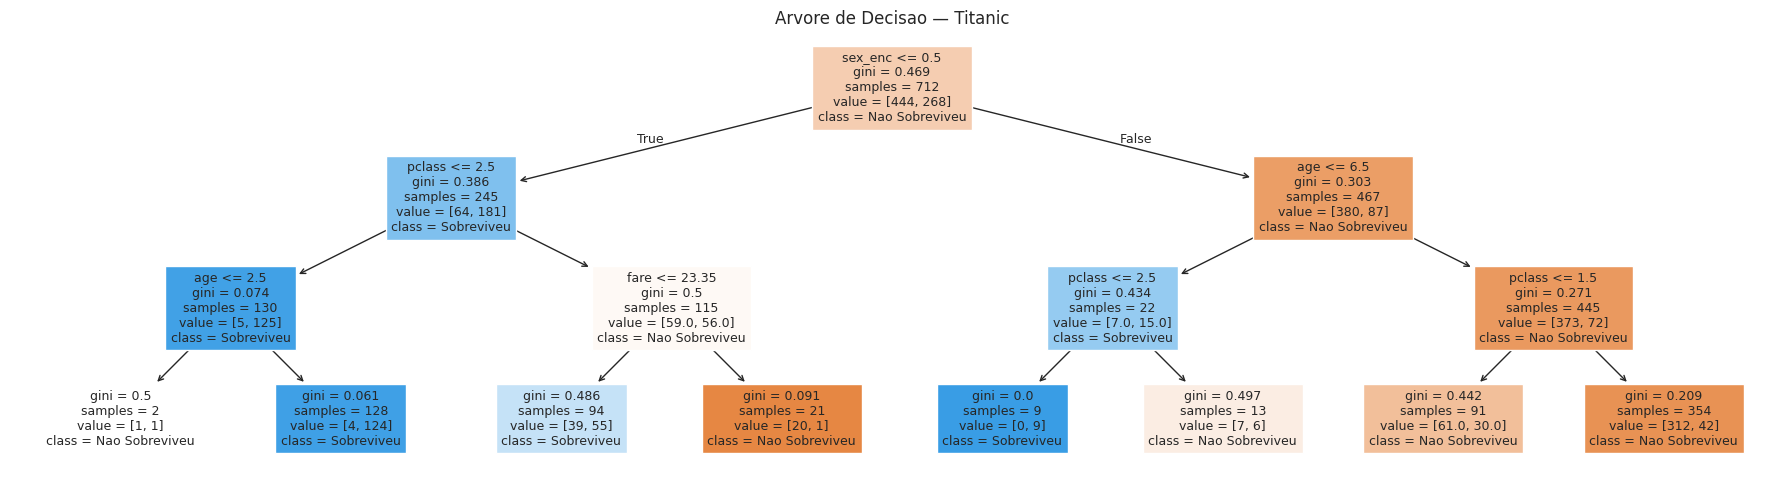

In [11]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

features_t = ["pclass", "sex_enc", "age", "fare"]
# adiciona colunas emb_ que existirem
features_t += [c for c in df_t.columns if c.startswith("emb")]

X_t = df_t[features_t]
y_t = df_t["survived"]

X_tr_t, X_te_t, y_tr_t, y_te_t = train_test_split(X_t, y_t, test_size=0.2, random_state=42)

clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_tr_t, y_tr_t)
y_pred_t = clf.predict(X_te_t)

print(f"Acurácia no Titanic: {accuracy_score(y_te_t, y_pred_t):.2%}")

# Visualização da árvore
plt.figure(figsize=(18, 5))
plot_tree(clf, feature_names=features_t,
          class_names=["Nao Sobreviveu", "Sobreviveu"], filled=True, fontsize=9)
plt.title("Arvore de Decisao — Titanic")
plt.tight_layout(); plt.show()

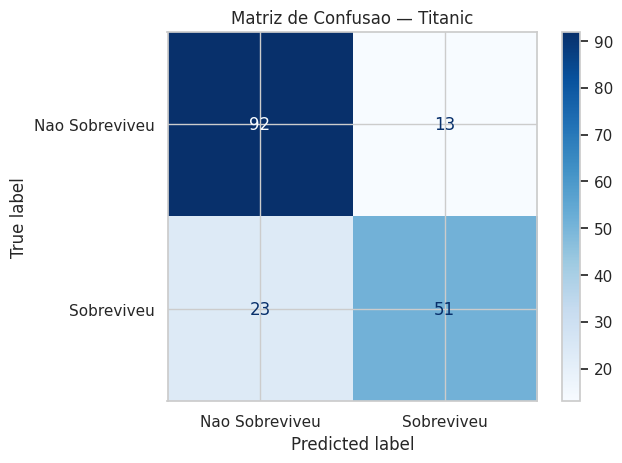

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_te_t, y_pred_t)
ConfusionMatrixDisplay(cm, display_labels=["Nao Sobreviveu", "Sobreviveu"]).plot(cmap="Blues")
plt.title("Matriz de Confusao — Titanic"); plt.show()

---
## 📏 Bloco 3 — Escalonamento de Variáveis
⏱️ *40–65 min*

### 3.1 Por que escalonar?

Imagine um modelo para prever o **preço de um imóvel** com duas variáveis:

- `quartos` → valores entre **1 e 5**
- `area_m2` → valores entre **30 e 500**

Sem escalonamento, o modelo pode interpretar `area_m2` como **muito mais importante** simplesmente por ter valores maiores — mesmo que os quartos sejam igualmente relevantes.

**Escalonar = colocar todas as variáveis na mesma escala, sem distorcer os dados.**

### 3.2 Três técnicas e suas fórmulas

| Técnica | Fórmula | Resultado | Melhor para |
|---|---|---|---|
| **Min-Max** (Normalização) | $(X - X_{min}) / (X_{max} - X_{min})$ | Intervalo $[0, 1]$ | Distribuição desconhecida, KNN, Redes Neurais |
| **Z-score** (Padronização) | $(X - \mu) / \sigma$ | Média=0, Desvio=1 | Distribuição normal, Regressão Linear |
| **Robust Scaler** | $(X - mediana) / (Q_3 - Q_1)$ | Robusto a outliers | Dados com muitos outliers |

> O **Robust Scaler** usa a mediana e o intervalo interquartil (IQR) em vez da média e do desvio, tornando-o resistente a valores extremos.

In [13]:
# Série de exemplo (inclui um outlier: 233)
X = np.array([1, 2, -3, 30, 13, 233])
print("Dados originais:", X)

# ── Min-Max ─────────────────────────────────────────────────────────────────
X_minmax = (X - X.min()) / (X.max() - X.min())
print("\nMin-Max (Normalização):", X_minmax.round(3))

# ── Z-score ─────────────────────────────────────────────────────────────────
X_zscore = (X - X.mean()) / X.std()
print("Z-score (Padronização):", X_zscore.round(3))

# ── Robust Scaler ───────────────────────────────────────────────────────────
Q1, med, Q3 = np.percentile(X, [25, 50, 75])
X_robust = (X - med) / (Q3 - Q1)
print("Robust Scaler:        ", X_robust.round(3))

# Tabela comparativa
df_comp = pd.DataFrame({
    "Original": X,
    "Min-Max":  X_minmax.round(3),
    "Z-score":  X_zscore.round(3),
    "Robust":   X_robust.round(3)
})
print("\nComparação:");
print(df_comp.to_string(index=False))
print("\n⚠️ Observe: o outlier 233 puxa Min-Max e Z-score para os extremos;")
print("   o Robust não sofre tanto pois usa mediana e IQR.")

Dados originais: [  1   2  -3  30  13 233]

Min-Max (Normalização): [0.017 0.021 0.    0.14  0.068 1.   ]
Z-score (Padronização): [-0.534 -0.522 -0.581 -0.19  -0.391  2.217]
Robust Scaler:         [-0.265 -0.224 -0.429  0.918  0.224  9.204]

Comparação:
 Original  Min-Max  Z-score  Robust
        1    0.017   -0.534  -0.265
        2    0.021   -0.522  -0.224
       -3    0.000   -0.581  -0.429
       30    0.140   -0.190   0.918
       13    0.068   -0.391   0.224
      233    1.000    2.217   9.204

⚠️ Observe: o outlier 233 puxa Min-Max e Z-score para os extremos;
   o Robust não sofre tanto pois usa mediana e IQR.


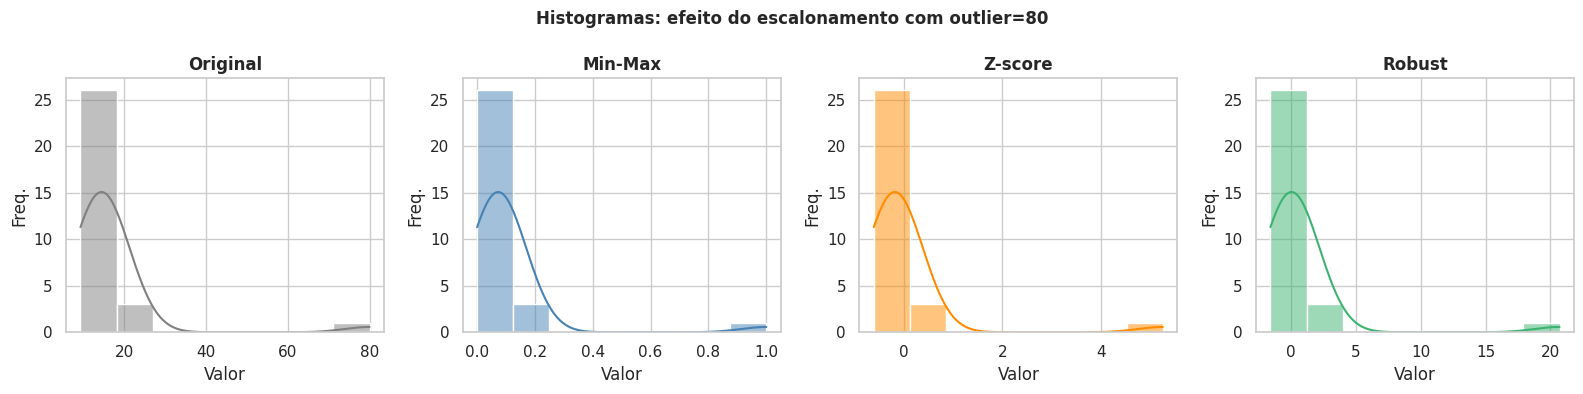


💡 A FORMA da distribuição é preservada — apenas a escala do eixo X muda.
   Observe que o Robust comprime menos os dados normais (15±3) do que o Min-Max.


In [14]:
# 📊 Histogramas: distribuição antes e depois do escalonamento
# (ref. Aula10: sns.histplot com kde=True)
np.random.seed(42)
X_hist = np.append(np.random.normal(loc=15, scale=3, size=29), 80)  # 29 normais + outlier=80
Xh2d = X_hist.reshape(-1, 1)

X_mm_h  = MinMaxScaler().fit_transform(Xh2d).flatten()
X_std_h = StandardScaler().fit_transform(Xh2d).flatten()
Q1h, medh, Q3h = np.percentile(X_hist, [25, 50, 75])
X_rob_h = (X_hist - medh) / (Q3h - Q1h)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
dados_plot = [("Original",  X_hist,   "gray"),
              ("Min-Max",   X_mm_h,   "steelblue"),
              ("Z-score",   X_std_h,  "darkorange"),
              ("Robust",    X_rob_h,  "mediumseagreen")]

for ax, (nome, dados, cor) in zip(axes, dados_plot):
    sns.histplot(dados, kde=True, ax=ax, color=cor, bins=8)
    ax.set_title(nome, fontweight="bold")
    ax.set_xlabel("Valor"); ax.set_ylabel("Freq.")

plt.suptitle("Histogramas: efeito do escalonamento com outlier=80",
             fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()
print("\n💡 A FORMA da distribuição é preservada — apenas a escala do eixo X muda.")
print("   Observe que o Robust comprime menos os dados normais (15±3) do que o Min-Max.")

### 3.3 Usando o scikit-learn — padrão de uso

```python
scaler = NomeDoScaler()                    # 1. Instanciar
X_transformado = scaler.fit_transform(X)   # 2. Ajustar e transformar (treino)
X_teste_trans  = scaler.transform(X_teste) # 3. Só transformar (teste — sem reajustar!)
```

> ⚠️ **Regra de ouro:** `.fit_transform()` só nos dados de **treino**. Nos dados de **teste**, use apenas `.transform()` — senão vaza informação!

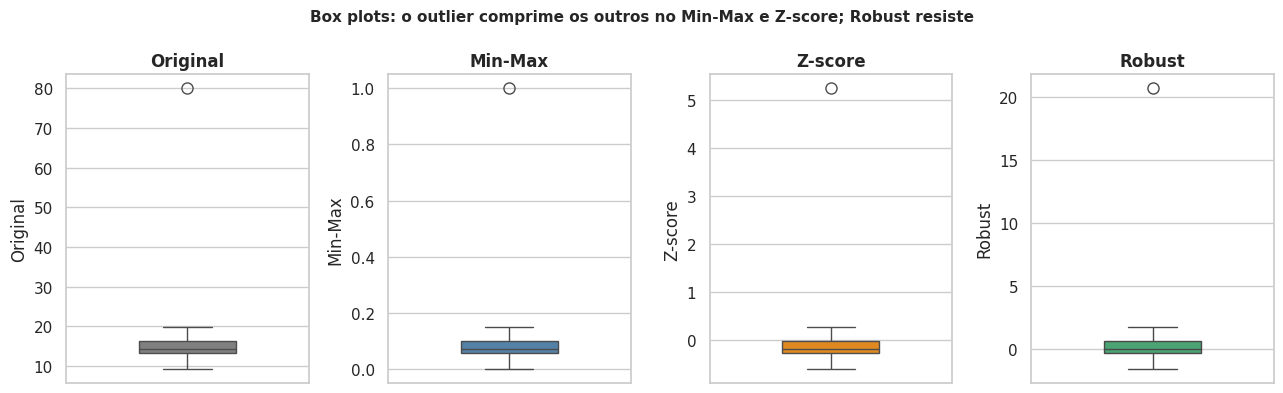


💡 No Min-Max, o outlier (=80) fica em 1.0 e comprime todos os demais para próximo de 0.
   O Robust usa mediana e IQR, então o outlier tem muito menos influência.


In [15]:
# 📊 Box plots: como o outlier (=80) é tratado por cada scaler
# (ref. Aula10: sns.boxplot para identificar outliers)
df_bp = pd.DataFrame({
    "Original": X_hist,
    "Min-Max":  X_mm_h,
    "Z-score":  X_std_h,
    "Robust":   X_rob_h
})

fig, axes = plt.subplots(1, 4, figsize=(13, 4))
cores_bp = ["gray", "steelblue", "darkorange", "mediumseagreen"]

for ax, (col, cor) in zip(axes, zip(df_bp.columns, cores_bp)):
    sns.boxplot(y=df_bp[col], ax=ax, color=cor, width=0.4, fliersize=8)
    ax.set_title(col, fontweight="bold")

plt.suptitle(
    "Box plots: o outlier comprime os outros no Min-Max e Z-score; Robust resiste",
    fontsize=11, fontweight="bold")
plt.tight_layout(); plt.show()
print("\n💡 No Min-Max, o outlier (=80) fica em 1.0 e comprime todos os demais para próximo de 0.")
print("   O Robust usa mediana e IQR, então o outlier tem muito menos influência.")

In [16]:
# sklearn — comparando os três scalers
X2d = X.reshape(-1, 1)   # sklearn exige array 2D

resultado = {}
for nome, scaler in [("Standard", StandardScaler()),
                     ("MinMax",   MinMaxScaler()),
                     ("Robust",   RobustScaler())]:
    transformado = scaler.fit_transform(X2d).flatten()
    resultado[nome] = transformado.round(3)

df_sklearn = pd.DataFrame(resultado, index=[f"X={v}" for v in X])
print("Resultado sklearn (confirma os cálculos manuais):")
print(df_sklearn)

Resultado sklearn (confirma os cálculos manuais):
       Standard  MinMax  Robust
X=1      -0.534   0.017  -0.265
X=2      -0.522   0.021  -0.224
X=-3     -0.581   0.000  -0.429
X=30     -0.190   0.140   0.918
X=13     -0.391   0.068   0.224
X=233     2.217   1.000   9.204


---
### ✏️ Exercício 2 — Escalonamento Guiado

Você tem dados de alunos com notas (0–10) e renda familiar (R$):

| Aluno | Redação | Matemática | Renda Familiar (R$) |
|---|---|---|---|
| Ana | 8 | 7 | 3.500 |
| Bruno | 5 | 9 | 12.000 |
| Carla | 9 | 4 | 850 |
| Diego | 6 | 6 | 45.000 |
| Eva | 7 | 8 | 2.200 |

**Siga os passos comentados abaixo:**

In [17]:
# ── Setup ───────────────────────────────────────────────────────────────────
df_ex2 = pd.DataFrame({
    "Aluno":      ["Ana", "Bruno", "Carla", "Diego", "Eva"],
    "redacao":    [8, 5, 9, 6, 7],
    "matematica": [7, 9, 4, 6, 8],
    "renda":      [3500, 12000, 850, 45000, 2200]
})
print("DataFrame inicial:"); print(df_ex2)

cols_num = ["redacao", "matematica", "renda"]

# ── Passo 1: aplique MinMaxScaler ────────────────────────────────────────────
# Dica: scaler = MinMaxScaler(); depois scaler.fit_transform(df_ex2[cols_num])
scaler_mm = MinMaxScaler()                                     # TODO
df_mm = pd.DataFrame(
    scaler_mm.fit_transform(df_ex2[cols_num]),                 # TODO
    columns=[c + "_mm" for c in cols_num],
    index=df_ex2["Aluno"]
)

# ── Passo 2: aplique StandardScaler ─────────────────────────────────────────
# Dica: mesma lógica, troque MinMaxScaler() por StandardScaler()
scaler_std = StandardScaler()                                  # TODO
df_std = pd.DataFrame(
    scaler_std.fit_transform(df_ex2[cols_num]),                # TODO
    columns=[c + "_std" for c in cols_num],
    index=df_ex2["Aluno"]
)

# ── Passo 3: compare e reflita ───────────────────────────────────────────────
resultado_ex2 = pd.concat([df_ex2.set_index("Aluno")[cols_num], df_mm, df_std], axis=1)
print("\nResultado (arredondado a 3 casas):")
print(resultado_ex2.round(3))

print("\n💡 Diego tem renda de R$45.000 — um outlier.")
print("   Observe como isso afeta a coluna renda_mm: ele fica em 1.0 e os demais ficam comprimidos.")
print("   Nesse caso, RobustScaler seria a melhor escolha!")

DataFrame inicial:
   Aluno  redacao  matematica  renda
0    Ana        8           7   3500
1  Bruno        5           9  12000
2  Carla        9           4    850
3  Diego        6           6  45000
4    Eva        7           8   2200

Resultado (arredondado a 3 casas):
       redacao  matematica  renda  redacao_mm  matematica_mm  renda_mm  \
Aluno                                                                    
Ana          8           7   3500        0.75            0.6     0.060   
Bruno        5           9  12000        0.00            1.0     0.253   
Carla        9           4    850        1.00            0.0     0.000   
Diego        6           6  45000        0.25            0.4     1.000   
Eva          7           8   2200        0.50            0.8     0.031   

       redacao_std  matematica_std  renda_std  
Aluno                                          
Ana          0.707           0.116     -0.555  
Bruno       -1.414           1.279     -0.043  
Carla       

---
### 🎬 [DEMONSTRAÇÃO] CatBoost — Previsão com Variáveis Categóricas

> **Demonstração avançada** — o professor executa, os alunos acompanham.
> **Objetivo:** mostrar que os dados preparados hoje (encoding + scaling) alimentam modelos mais sofisticados nas próximas aulas.

> O **CatBoost** é um algoritmo que trata variáveis categóricas automaticamente, sem necessidade de encoding manual — muito poderoso na prática.

In [18]:
# Verificação e instalação do CatBoost
import subprocess, sys

try:
    from catboost import CatBoostRegressor
    import catboost
    print(f"✅ CatBoost já instalado — versão {catboost.__version__}")
except ImportError:
    print("⚠️ Instalando CatBoost, aguarde (pode levar ~30 segundos)...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "catboost", "--quiet"])
    from catboost import CatBoostRegressor
    import catboost
    print(f"✅ CatBoost instalado — versão {catboost.__version__}")

⚠️ Instalando CatBoost, aguarde (pode levar ~30 segundos)...
✅ CatBoost instalado — versão 1.2.10


In [19]:
from catboost import CatBoostRegressor

# Gerando dados sintéticos com estrutura de desempenho escolar
np.random.seed(42)
n = 600

df_students = pd.DataFrame({
    "gender":      np.random.choice(["male", "female"], n),
    "ethnicity":   np.random.choice(["group A","group B","group C","group D","group E"], n),
    "parental_edu":np.random.choice(["high school","some college",
                                     "associate degree","bachelor degree","master degree"], n),
    "lunch":       np.random.choice(["standard", "free/reduced"], n),
    "test_prep":   np.random.choice(["none", "completed"], n),
    "reading":     np.random.randint(30, 100, n).astype(float),
    "writing":     np.random.randint(30, 100, n).astype(float),
})

# Alvo: nota de matemática (com relação real)
df_students["math"] = (
    0.4 * df_students["reading"]
    + 0.4 * df_students["writing"]
    + 4 * (df_students["lunch"] == "standard").astype(int)
    + 3 * (df_students["test_prep"] == "completed").astype(int)
    + np.random.normal(0, 5, n)
).clip(0, 100)

print("Amostra:"); print(df_students.head())
print(f"\nShape: {df_students.shape}")

Amostra:
   gender ethnicity     parental_edu         lunch  test_prep  reading  \
0    male   group E     some college      standard  completed     61.0   
1  female   group D      high school  free/reduced  completed     61.0   
2    male   group C    master degree  free/reduced       none     40.0   
3    male   group D  bachelor degree  free/reduced  completed     39.0   
4    male   group E    master degree      standard       none     44.0   

   writing       math  
0     50.0  56.374908  
1     83.0  59.787369  
2     47.0  40.334952  
3     65.0  40.063700  
4     74.0  45.780946  

Shape: (600, 8)


R²  = 0.82  
MAE = 4.22 pontos


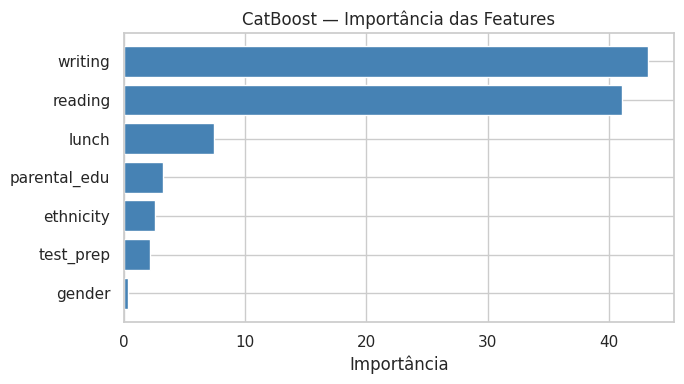

In [20]:
# Features e alvo
y_cat = df_students["math"]
X_cat = df_students.drop(columns=["math"]).copy()

cat_features = ["gender", "ethnicity", "parental_edu", "lunch", "test_prep"]
num_features  = ["reading", "writing"]

# Escalonamento das features numéricas
sc_cat = StandardScaler()
X_cat[num_features] = sc_cat.fit_transform(X_cat[num_features])

X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(
    X_cat, y_cat, test_size=0.2, random_state=42)

# Modelo CatBoost
model_cat = CatBoostRegressor(
    iterations=300, learning_rate=0.05, depth=5,
    cat_features=cat_features, verbose=0, random_state=42)

model_cat.fit(X_tr_c, y_tr_c)
y_pred_c = model_cat.predict(X_te_c)

print(f"R²  = {r2_score(y_te_c, y_pred_c):.2f}  ")
print(f"MAE = {mean_absolute_error(y_te_c, y_pred_c):.2f} pontos")

# Importância das features
imp = pd.DataFrame({
    "feature":    X_cat.columns.tolist(),
    "importancia": model_cat.get_feature_importance()
}).sort_values("importancia", ascending=True)

plt.figure(figsize=(7, 4))
plt.barh(imp["feature"], imp["importancia"], color="steelblue")
plt.title("CatBoost — Importância das Features")
plt.xlabel("Importância"); plt.tight_layout(); plt.show()

---
## 🤖 Bloco 4 — Introdução ao Machine Learning
⏱️ *65–80 min*

### 4.1 O que é Machine Learning?

**Machine Learning (ML)** é um campo da Inteligência Artificial que permite que computadores **aprendam padrões a partir de dados**, sem serem explicitamente programados.

#### Dois grandes paradigmas

| Paradigma | Como funciona | Exemplo |
|---|---|---|
| **Supervisionado** | Aprende com dados **rotulados** (entrada + resposta correta conhecida) | Prever preço de imóvel, classificar e-mail como spam |
| **Não Supervisionado** | Encontra padrões em dados **sem rótulos** | Agrupar clientes por comportamento de compra |

> **Analogia Supervisionado:** aprender com um professor que mostra a foto do animal e diz o nome.
> **Analogia Não Supervisionado:** explorar uma caixa com frutas misturadas e agrupá-las por semelhança.

### 4.2 Tipos de Problemas de ML

| Tipo | Pergunta central | Saída | Exemplo |
|---|---|---|---|
| **Regressão** | *Quanto? Qual valor?* | Número contínuo | Preço de imóvel, custo de seguro |
| **Classificação** | *Qual classe? Qual grupo?* | Categoria discreta | Spam ou não? Sobreviveu? |
| **Clustering** | *Como organizar?* | Grupos (sem rótulo) | Segmentar clientes |

> Regressão e Classificação → **supervisionados**. Clustering → **não supervisionado**.

#### 🧠 Fixação rápida
Para cada cenário, identifique o tipo:
1. Prever se um e-mail é spam ou não-spam.
2. Estimar o salário de um candidato com base em anos de experiência.
3. Agrupar 10 mil músicas em playlists sem conhecer os gêneros.

*(Resposta: 1→Classificação, 2→Regressão, 3→Clustering)*

### 4.3 A Regra de Ouro: Treino e Teste

> ❌ **Nunca use os mesmos dados para treinar e avaliar o modelo!**

Se o modelo ver os dados de teste durante o treino, ele pode simplesmente **"decorar"** as respostas em vez de aprender a generalizar.

```
📂 Dataset
  ├── 80% → Treino   (o modelo aprende aqui)
  └── 20% → Teste    (avaliamos o modelo com dados nunca vistos)
```

**Analogia:** Treino = material de estudo. Teste = prova final com questões novas.

In [21]:
# Demonstração: train_test_split
np.random.seed(42)
dados_demo = pd.DataFrame({
    "horas_estudo": np.random.rand(1000) * 10,
    "nota_final":   np.random.rand(1000) * 100
})

X_demo = dados_demo[["horas_estudo"]]
y_demo = dados_demo["nota_final"]

# test_size=0.2 → 20% para teste
# random_state=42 → garante que a divisão seja sempre a mesma (reprodutibilidade)
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X_demo, y_demo, test_size=0.2, random_state=42
)

print(f"Total de amostras  : {len(dados_demo)}")
print(f"Amostras de treino : {len(X_treino)}  ({len(X_treino)/len(dados_demo):.0%})")
print(f"Amostras de teste  : {len(X_teste)}   ({len(X_teste)/len(dados_demo):.0%})")

Total de amostras  : 1000
Amostras de treino : 800  (80%)
Amostras de teste  : 200   (20%)


### 4.4 Overfitting e Underfitting

| Situação | Descrição | Sintoma |
|---|---|---|
| **Underfitting** (Subajuste) | Modelo simples demais — não aprendeu | Erro **alto** no treino e no teste |
| **Bom Ajuste** | Aprendeu os padrões reais | Erros **próximos** e **baixos** |
| **Overfitting** (Sobreajuste) | Modelo decorou o treino com ruído | Erro **baixo** no treino, **alto** no teste |

> **Analogia Overfitting:** decorar as respostas da lista de exercícios (treino), mas não saber resolver questões novas na prova (teste).

> **Como diagnosticar?** Compare o erro do treino com o erro do teste:
> - Erros parecidos e baixos → Bom Ajuste ✅
> - Grande diferença (treino bom, teste ruim) → Overfitting ⚠️
> - Erros altos nos dois → Underfitting ⚠️

---
### ✏️ Exercício 3 — Diagnóstico de Over/Underfitting

Analise os resultados abaixo e identifique o cenário mais provável:

| Cenário | Erro Treino | Erro Teste | Diagnóstico |
|---|---|---|---|
| A | 2% | 3% | ? |
| B | 1% | 35% | ? |
| C | 28% | 30% | ? |

**Pistas:**
- Erros parecidos e baixos → Bom Ajuste
- Diferença grande (treino ótimo, teste ruim) → Overfitting
- Erros altos nos dois → Underfitting

In [22]:
# Complete com "Bom Ajuste", "Overfitting" ou "Underfitting"
respostas = {
    "Cenario A (Treino=2%, Teste=3%)":    "TODO — Bom Ajuste / Overfitting / Underfitting?",  # TODO
    "Cenario B (Treino=1%, Teste=35%)":   "TODO — Bom Ajuste / Overfitting / Underfitting?",  # TODO
    "Cenario C (Treino=28%, Teste=30%)":  "TODO — Bom Ajuste / Overfitting / Underfitting?",  # TODO
}

for cenario, resposta in respostas.items():
    print(f"{cenario}: {resposta}")

# ── Gabarito (descomente para conferir) ─────────────────────────────────────
# print("\nGabarito:")
# print("Cenario A: Bom Ajuste  — erros próximos e baixos")
# print("Cenario B: Overfitting — treino ótimo, teste péssimo")
# print("Cenario C: Underfitting — erros altos nos dois conjuntos")

Cenario A (Treino=2%, Teste=3%): TODO — Bom Ajuste / Overfitting / Underfitting?
Cenario B (Treino=1%, Teste=35%): TODO — Bom Ajuste / Overfitting / Underfitting?
Cenario C (Treino=28%, Teste=30%): TODO — Bom Ajuste / Overfitting / Underfitting?


---
## 🏥 Bloco 5 — Projeto Integrado: Previsão de Custos de Seguro Saúde
⏱️ *80–90 min*

Vamos aplicar **todo o pipeline** aprendido hoje em um projeto real:

```
📂 insurance.csv  →  🔤 Encoding  →  📏 Scaling  →  ✂️ Treino/Teste  →  🤖 Regressão Linear
```

**Dataset:** Medical Cost Personal — features: idade, sexo, IMC, filhos, fumante, região
**Problema:** Regressão — prever o custo médico (`charges`)

In [23]:
# Carregando o dataset diretamente da URL pública
url_seguro = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
df_seguro = pd.read_csv(url_seguro)

print(f"Shape: {df_seguro.shape}")
print("\nAmostra:"); print(df_seguro.head())
print("\nTipos:\n", df_seguro.dtypes)
print("\nValores nulos:\n", df_seguro.isnull().sum())

Shape: (1338, 7)

Amostra:
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

Tipos:
 age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

Valores nulos:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


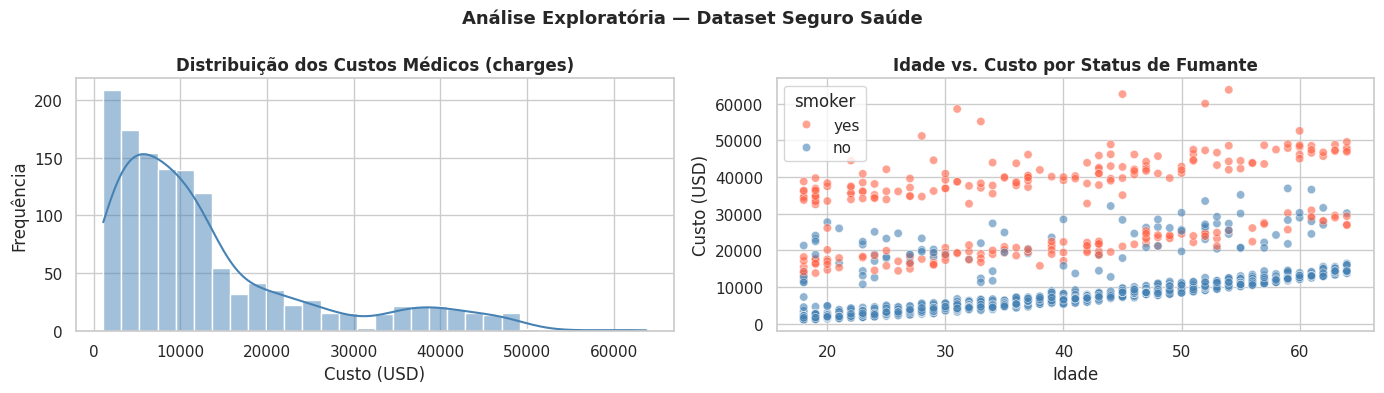


💡 Histograma: distribuição assimétrica (skewed right) — muitos custos baixos, poucos extremos.
   Scatter: fumantes (vermelho) têm custos sistematicamente maiores — variável crucial!


In [24]:
# 📊 Análise exploratória: distribuição do alvo e relação entre variáveis
# (ref. Aula10: sns.histplot com kde=True  +  sns.scatterplot com hue)
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histograma do alvo (charges)
sns.histplot(df_seguro["charges"], kde=True, bins=30,
             color="steelblue", ax=axes[0])
axes[0].set_title("Distribuição dos Custos Médicos (charges)", fontweight="bold")
axes[0].set_xlabel("Custo (USD)"); axes[0].set_ylabel("Frequência")

# Scatter: idade vs custo, colorido por fumante
sns.scatterplot(data=df_seguro, x="age", y="charges", hue="smoker",
                palette={"yes": "tomato", "no": "steelblue"},
                alpha=0.6, ax=axes[1])
axes[1].set_title("Idade vs. Custo por Status de Fumante", fontweight="bold")
axes[1].set_xlabel("Idade"); axes[1].set_ylabel("Custo (USD)")

plt.suptitle("Análise Exploratória — Dataset Seguro Saúde",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

print("\n💡 Histograma: distribuição assimétrica (skewed right) — muitos custos baixos, poucos extremos.")
print("   Scatter: fumantes (vermelho) têm custos sistematicamente maiores — variável crucial!")

In [25]:
# ── Passo 1: Encoding das variáveis categóricas ─────────────────────────────
# sex e smoker são binárias; region tem 4 categorias
df_seg_proc = pd.get_dummies(df_seguro, columns=["sex", "smoker", "region"], drop_first=True)

# Convertendo colunas booleanas para inteiro (0/1)
bool_cols = df_seg_proc.select_dtypes(include="bool").columns
df_seg_proc[bool_cols] = df_seg_proc[bool_cols].astype(int)

print("Colunas após encoding:"); print(df_seg_proc.columns.tolist())
print("\nAmostra:"); print(df_seg_proc.head())

Colunas após encoding:
['age', 'bmi', 'children', 'charges', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']

Amostra:
   age     bmi  children      charges  sex_male  smoker_yes  region_northwest  \
0   19  27.900         0  16884.92400         0           1                 0   
1   18  33.770         1   1725.55230         1           0                 0   
2   28  33.000         3   4449.46200         1           0                 0   
3   33  22.705         0  21984.47061         1           0                 1   
4   32  28.880         0   3866.85520         1           0                 1   

   region_southeast  region_southwest  
0                 0                 1  
1                 1                 0  
2                 1                 0  
3                 0                 0  
4                 0                 0  


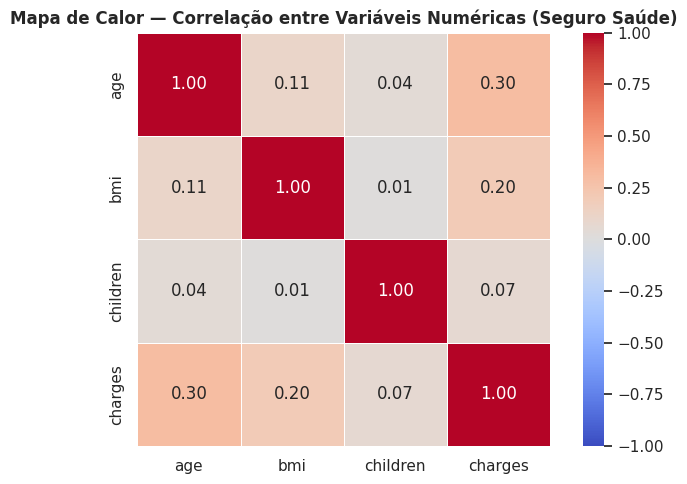


💡 charges tem maior correlação numérica com age (0.30) e bmi (0.20).
   A variável smoker (categórica, ausente aqui) é a mais preditiva — o encoding
   que fizemos no Passo 1 é essencial para o modelo capturar esse efeito!


In [26]:
# 📊 Mapa de Calor: correlação entre variáveis numéricas
# (ref. Aula10: sns.heatmap com annot=True, cmap="coolwarm")
num_seg = df_seguro.select_dtypes(include="number")
corr_seg = num_seg.corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr_seg, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, square=True, vmin=-1, vmax=1)
plt.title("Mapa de Calor — Correlação entre Variáveis Numéricas (Seguro Saúde)",
          fontweight="bold")
plt.tight_layout(); plt.show()

print("\n💡 charges tem maior correlação numérica com age (0.30) e bmi (0.20).")
print("   A variável smoker (categórica, ausente aqui) é a mais preditiva — o encoding")
print("   que fizemos no Passo 1 é essencial para o modelo capturar esse efeito!")

In [27]:
# ── Passo 2: Separando features e alvo ─────────────────────────────────────
X_seg = df_seg_proc.drop("charges", axis=1)
y_seg = df_seg_proc["charges"]

# ── Passo 3: Escalonamento ─────────────────────────────────────────────────
scaler_seg = StandardScaler()
X_seg_scaled = pd.DataFrame(
    scaler_seg.fit_transform(X_seg),
    columns=X_seg.columns
)

# ── Passo 4: Divisão Treino / Teste ────────────────────────────────────────
X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(
    X_seg_scaled, y_seg, test_size=0.2, random_state=42)

print(f"Treino: {X_tr_s.shape[0]} amostras  |  Teste: {X_te_s.shape[0]} amostras")

Treino: 1070 amostras  |  Teste: 268 amostras


In [28]:
# ── Passo 5: Treinando a Regressão Linear ──────────────────────────────────
modelo_seg = LinearRegression()
modelo_seg.fit(X_tr_s, y_tr_s)

previsoes_seg = modelo_seg.predict(X_te_s)

mae_seg = mean_absolute_error(y_te_s, previsoes_seg)
r2_seg  = r2_score(y_te_s, previsoes_seg)

print("══════════════════════════════════════════")
print(f"  Erro Médio Absoluto (MAE) : ${mae_seg:,.2f}")
print(f"  Coef. Determinação  (R²)  : {r2_seg:.2f}")
print("══════════════════════════════════════════")
print(f"\nInterpretação:")
print(f"  O modelo explica {r2_seg*100:.0f}% da variação nos custos.")
print(f"  O erro médio por pessoa é de ${mae_seg:,.0f}.")

══════════════════════════════════════════
  Erro Médio Absoluto (MAE) : $4,181.19
  Coef. Determinação  (R²)  : 0.78
══════════════════════════════════════════

Interpretação:
  O modelo explica 78% da variação nos custos.
  O erro médio por pessoa é de $4,181.


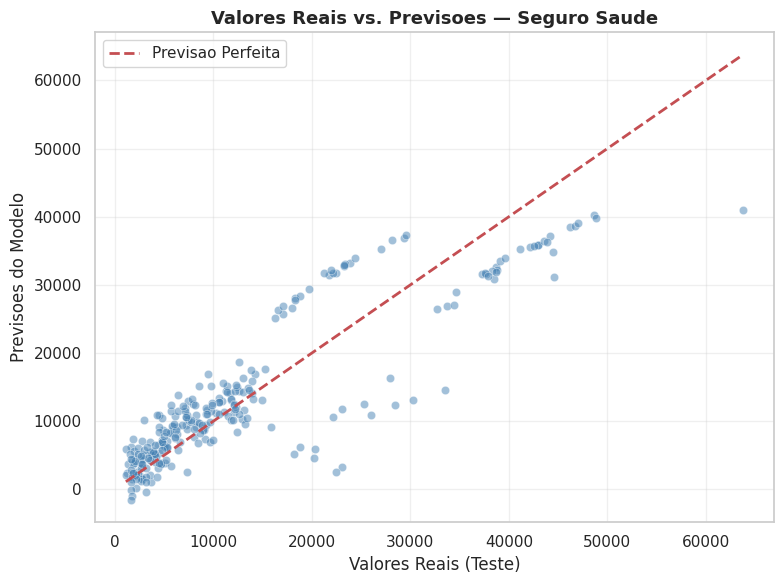


💡 Pontos próximos à linha vermelha = boas previsões.
   Pontos afastados = erros maiores — casos que o modelo não explicou bem.
   Na próxima aula: como melhorar usando outros algoritmos!


In [29]:
# ── Passo 6: Visualização — Valores Reais vs. Previstos ────────────────────
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_te_s, y=previsoes_seg, alpha=0.5, color="steelblue")
plt.plot([y_te_s.min(), y_te_s.max()],
         [y_te_s.min(), y_te_s.max()], "r--", linewidth=2, label="Previsao Perfeita")

plt.xlabel("Valores Reais (Teste)",  fontsize=12)
plt.ylabel("Previsoes do Modelo",    fontsize=12)
plt.title("Valores Reais vs. Previsoes — Seguro Saude", fontsize=13, fontweight="bold")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.show()

print("\n💡 Pontos próximos à linha vermelha = boas previsões.")
print("   Pontos afastados = erros maiores — casos que o modelo não explicou bem.")
print("   Na próxima aula: como melhorar usando outros algoritmos!")

---
## 🏁 Resumo da Aula

| Tópico | O que aprendemos |
|---|---|
| **Encoding** | Converter categorias em números sem criar informações falsas |
| **Label Encoding** | Para variáveis ordinais — preserva a ordem com mapeamento manual |
| **One-Hot / get_dummies** | Para variáveis nominais — `drop_first=True` evita multicolinearidade |
| **Min-Max Scaling** | Normaliza para o intervalo $[0, 1]$ |
| **Z-score** | Padroniza para média=0, desvio=1 — ótimo para distribuições normais |
| **Robust Scaler** | Usa mediana e IQR — resistente a outliers |
| **ML Supervisionado** | Aprende com dados rotulados; resolve Regressão e Classificação |
| **Train/Test Split** | Separar dados é essencial para avaliar a real capacidade do modelo |
| **Over/Underfitting** | Diagnosticado comparando erros de treino e de teste |

---
*Prof. Domingos Napolitano — Programação para Análise de Dados — IBMEC*